## 0. Etape préparatoire

# Importer les bibliothèques nécéssaires ainsi que le jeu de données :

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as  plt
import seaborn as sns

from wordcloud import WordCloud
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import unicodedata
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy

nltk.download('wordnet')
nltk.download('stopwords')
nltk.download('punkt')

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.model_selection import learning_curve

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\gauth\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\gauth\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\gauth\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [28]:
pd.set_option('display.max_row', 111)
pd.set_option('display.max_column', 111)

In [29]:
data_train = pd.read_json('C:/Users/gauth/Desktop/Projet-Code/Python/IA/Projet DATA-Mining/data/train.jsonl', lines=True)
data_test = pd.read_json('C:/Users/gauth/Desktop/Projet-Code/Python/IA/Projet DATA-Mining/data/test.jsonl', lines=True)

In [30]:
data_train.head()

,OGC_FID,boamp_id_annonce,boamp_parent_annonce,boamp_theme_boamp,boamp_libelle_annonce,boamp_statut_annonce,boamp_date_fin_de_marche,boamp_num_departement_diffusion,boamp_nom_acheteur,boamp_siret_acheteur,boamp_type_organisme,boamp_lieu_exec,boamp_intitule,cal_fichier_pdf,cal_num_signalement,cal_theme_signalement,cal_réponse_signalement,cal_statut_workflow,cal_mot_rang_1,cal_mot_rang_2,cal_date_traitement,cal_type_localisation,cal_num_departement_exec,cal_siren_epci,cal_insee_commune_exec,cal_nom_commune_exec,cal_adresse_annonce,texte_annonce
0,9723,23-177335,None,Espaces verts,Avis de marché,INITIAL,2024-02-02,31,TOULOUSE METROPOLE,24310051800170,TOULOUSE METROPOLE,,Travaux d'aménagement de l'île du Ramier à Tou...,https://fr.ftp.opendatasoft.com/datadila/BOAMP...,828298,Route,Pris en compte,50-signalement posté,travaux,aménagement,2023-12-22,loc_intitule_poi,31,243100518,31555,TOULOUSE,DÉCHÈTERIE DU RAMIER,Avis n° 23-177335\n \nAttention : les informa...
1,10502,24-63002,None,Station d'épuration (travaux),Avis de marché,INITIAL,2024-08-08,09,Syndicat Mixte Départemental de l'Eau et de l'...,25090187300019,COMMUNE,Parcelle n° 142 de la section ZB 09340 - VERNI...,Travaux de construction de la nouvelle station...,https://www.boamp.fr/telechargements/FILES/PDF...,870008,Points d'intérêt,Pris en compte,50-signalement posté,nouvelle,station,2024-05-30,loc_intitule_commune,9,,09332,VERNIOLLE,,1/3\nAvis de marché\nAttention : les informat...
2,10900,24-94957,['24-79402'],Voirie et réseaux divers,Rectificatif,RECTIFICATIF,2024-08-23,33,Bordeaux Métropole,24330031600011,,,"Aménagement de la place de la Renaudel, rues ...",https://www.boamp.fr/telechargements/FILES/PDF...,899670,Route,Pris en compte,50-signalement posté,aménagement,place,2024-08-14,loc_intitule_poi,33,243300316,33063,BORDEAUX,ÉGLISE SAINT LOUIS,1/1\nAvis rectificatif\nAttention : les infor...
3,779,23-179664,None,"Prestations de services, Délégation de service...",Avis de marché,INITIAL,2024-04-16,75,Ville de Paris,,,,Rénovation du parc de stationnement St Martin ...,https://fr.ftp.opendatasoft.com/datadila/BOAMP...,829274,Points d'intérêt,Rejete (hors specs),50-signalement posté,transformation,parc,2023-12-29,loc_acheteur_commune,75,,75056,PARIS,,Avis n° 23-179664\n \nAttention : les informa...
4,5614,24-69326,None,Génie civil,Avis de marché,INITIAL,2024-07-11,43,Département de la Haute-Loire,22430001200016,,Lieu-dit &quot;Basset&quot; 43210 - BAS-EN-BASSET,Rd12 - Reconstruction Du Pont Sur La Loire A B...,https://www.boamp.fr/telechargements/FILES/PDF...,876552,Route,Pris en compte,50-signalement posté,reconstruction,pont,2024-06-14,loc_lieu_exec_poi,43,,43020,BAS EN BASSET,BASSET,1/2\nAvis de marché\nAttention : les informat...


In [ ]:
data_train.to_excel('C:/Users/gauth/Desktop/Projet-Code/Python/IA/Projet DATA-Mining/data/data_train.xlsx', index=False)

In [ ]:
data_test.to_excel('C:/Users/gauth/Desktop/Projet-Code/Python/IA/Projet DATA-Mining/data/data_test.xlsx', index=False)

## 1. Exploration des Données

# Objectif :

- Comprendre du mieux possible nos données (un petit pas en avant vaut mieux qu'un grand pas en arrière)
- Développer une première stratégie de modélisation


# Checklist de base :

Analyse de Forme :

- Variable target (classe) : cal_réponse_signalement
- Lignes et Colonnes : 5000, 28
- Types de variables : Qualitatives = 28
- Analyse des valeurs manquantes : beaucoup de NAN ( 2 variables > 80% de NAN )

Analyse de Fond :

- Visualisation de la target : 
    - 73% de cas positifs contre 27 % de cas négatifs
- Signification des variables :
    -Très peu de variables continues. Pas d'information intéressante a relever au premier abord
- Relation Variable / Target :

## Analyse de la forme des données :

Créer une copie de notre data frame

In [8]:
df = data_train.copy()

Voir le nombre de lignes et de colonnes

In [9]:
df.shape

(5000, 28)

Voir la répartition du type des colonnes

In [10]:
df.dtypes.value_counts()

object    25
int64      3
Name: count, dtype: int64

<Axes: ylabel='count'>

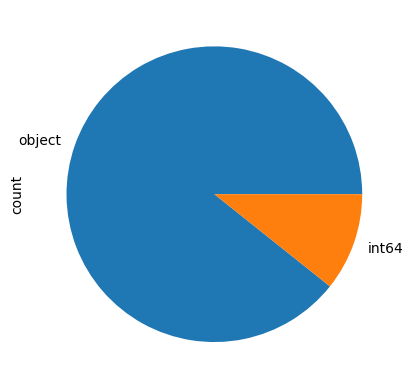

In [11]:
df.dtypes.value_counts().plot.pie()

Analyser les valeurs nulles

In [17]:
#Formater les valeurs nulles en NA
df.replace("None", np.nan, inplace=True)
df.replace("", np.nan, inplace=True)

<Axes: >

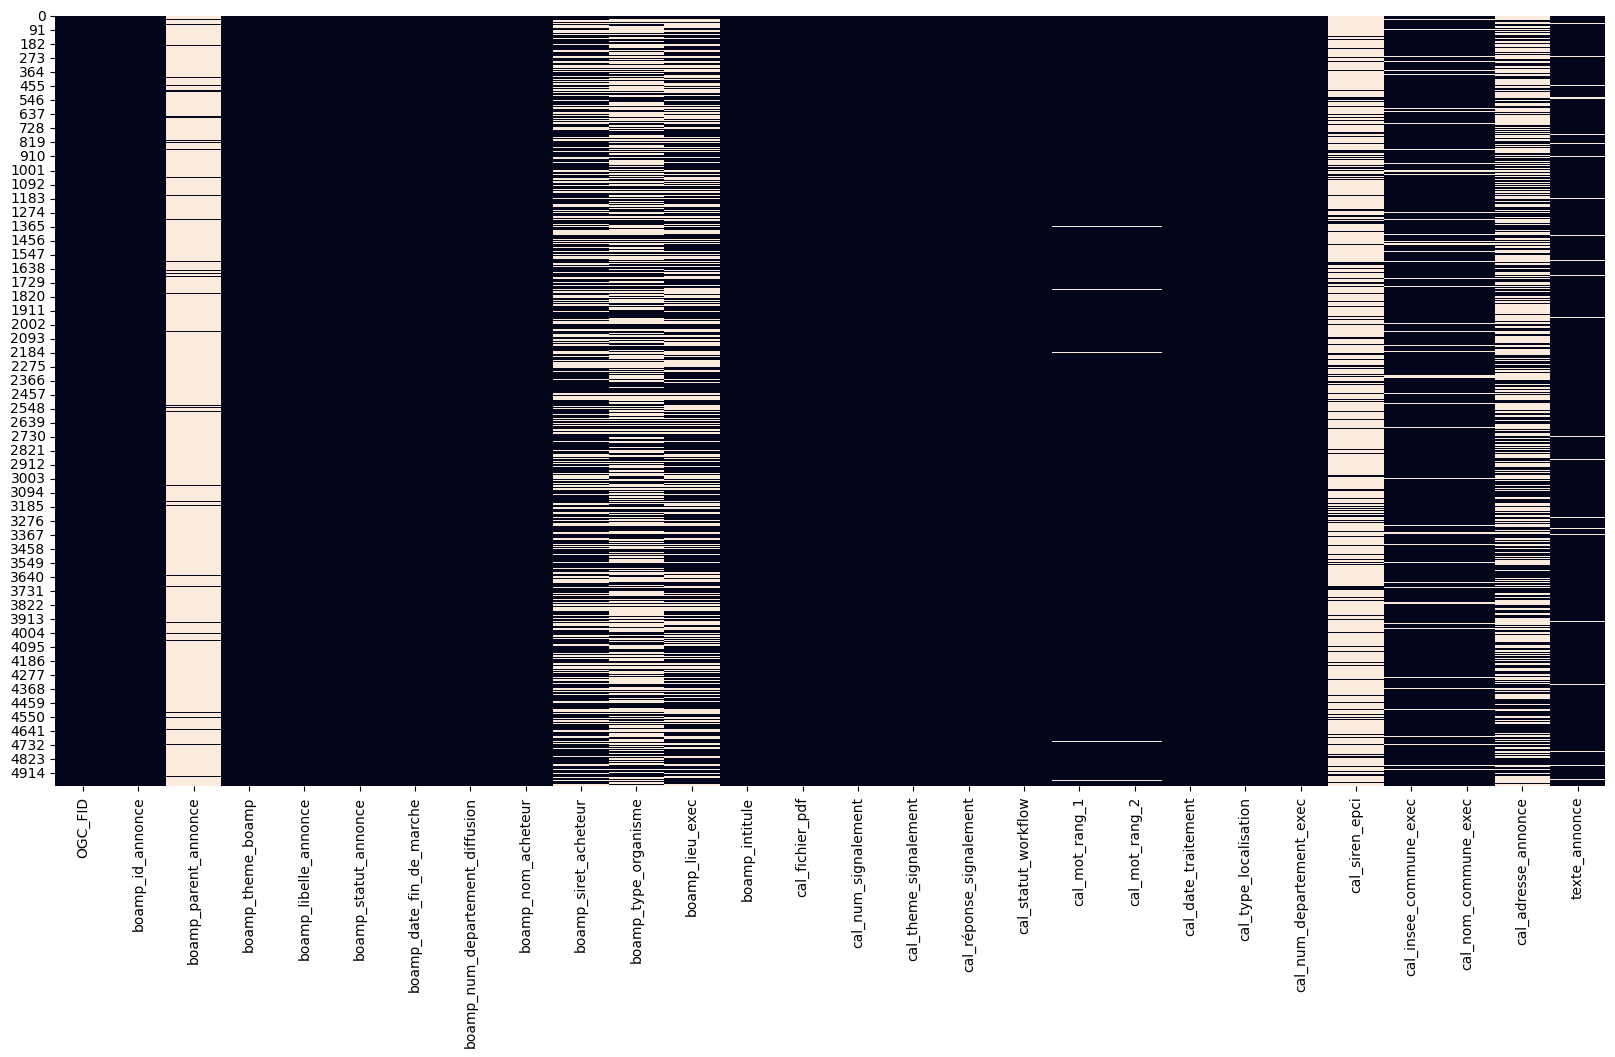

In [18]:
#Visualiser le dataframe et les valeurs nulles
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

In [19]:
(df.isna().sum() / df.shape[0]).sort_values(ascending=True)

OGC_FID                            0.0000
boamp_id_annonce                   0.0000
boamp_theme_boamp                  0.0000
boamp_libelle_annonce              0.0000
boamp_date_fin_de_marche           0.0000
boamp_statut_annonce               0.0000
boamp_num_departement_diffusion    0.0000
boamp_nom_acheteur                 0.0000
cal_theme_signalement              0.0000
cal_num_signalement                0.0000
cal_fichier_pdf                    0.0000
boamp_intitule                     0.0000
cal_date_traitement                0.0000
cal_num_departement_exec           0.0000
cal_statut_workflow                0.0000
cal_réponse_signalement            0.0000
cal_type_localisation              0.0002
cal_mot_rang_1                     0.0024
cal_mot_rang_2                     0.0024
texte_annonce                      0.0342
cal_nom_commune_exec               0.0596
cal_insee_commune_exec             0.0596
boamp_siret_acheteur               0.3396
boamp_lieu_exec                   

## Analyse de Fond

# 1. Visualisation initiale - Elimination des colonnes inutiles

In [20]:
df = df[df.columns[df.isna().sum()/df.shape[0] < 0.8]] #Supprimer les colonnes avec plus de 80% données manquantes

<Axes: >

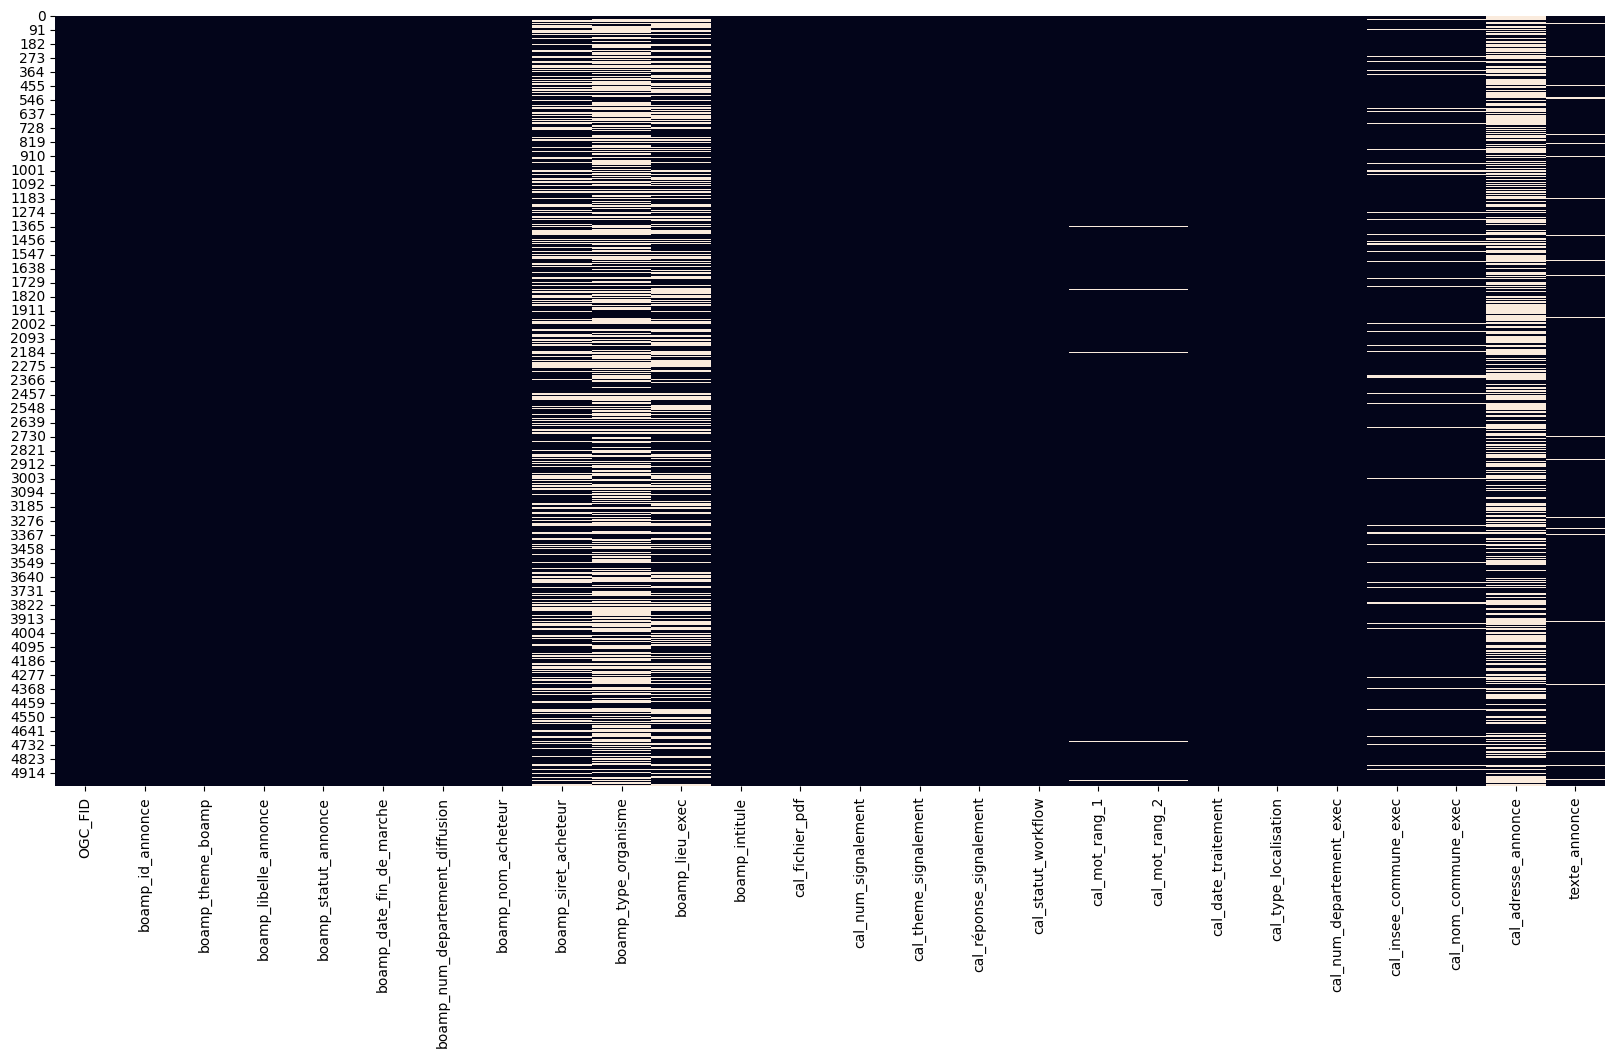

In [21]:
plt.figure(figsize=(20,10))
sns.heatmap(df.isna(), cbar=False)

In [22]:
df = df.drop('OGC_FID', axis=1)
df = df.drop('boamp_id_annonce', axis=1)
df = df.drop('cal_fichier_pdf', axis=1)

In [23]:
df.head()

,boamp_theme_boamp,boamp_libelle_annonce,boamp_statut_annonce,boamp_date_fin_de_marche,boamp_num_departement_diffusion,boamp_nom_acheteur,boamp_siret_acheteur,boamp_type_organisme,boamp_lieu_exec,boamp_intitule,cal_num_signalement,cal_theme_signalement,cal_réponse_signalement,cal_statut_workflow,cal_mot_rang_1,cal_mot_rang_2,cal_date_traitement,cal_type_localisation,cal_num_departement_exec,cal_insee_commune_exec,cal_nom_commune_exec,cal_adresse_annonce,texte_annonce
0,Espaces verts,Avis de marché,INITIAL,2024-02-02,31,TOULOUSE METROPOLE,24310051800170,TOULOUSE METROPOLE,NaN,Travaux d'aménagement de l'île du Ramier à Tou...,828298,Route,Pris en compte,50-signalement posté,travaux,aménagement,2023-12-22,loc_intitule_poi,31,31555,TOULOUSE,DÉCHÈTERIE DU RAMIER,Avis n° 23-177335\n \nAttention : les informa...
1,Station d'épuration (travaux),Avis de marché,INITIAL,2024-08-08,09,Syndicat Mixte Départemental de l'Eau et de l'...,25090187300019,COMMUNE,Parcelle n° 142 de la section ZB 09340 - VERNI...,Travaux de construction de la nouvelle station...,870008,Points d'intérêt,Pris en compte,50-signalement posté,nouvelle,station,2024-05-30,loc_intitule_commune,9,09332,VERNIOLLE,NaN,1/3\nAvis de marché\nAttention : les informat...
2,Voirie et réseaux divers,Rectificatif,RECTIFICATIF,2024-08-23,33,Bordeaux Métropole,24330031600011,NaN,NaN,"Aménagement de la place de la Renaudel, rues ...",899670,Route,Pris en compte,50-signalement posté,aménagement,place,2024-08-14,loc_intitule_poi,33,33063,BORDEAUX,ÉGLISE SAINT LOUIS,1/1\nAvis rectificatif\nAttention : les infor...
3,"Prestations de services, Délégation de service...",Avis de marché,INITIAL,2024-04-16,75,Ville de Paris,NaN,NaN,NaN,Rénovation du parc de stationnement St Martin ...,829274,Points d'intérêt,Rejete (hors specs),50-signalement posté,transformation,parc,2023-12-29,loc_acheteur_commune,75,75056,PARIS,NaN,Avis n° 23-179664\n \nAttention : les informa...
4,Génie civil,Avis de marché,INITIAL,2024-07-11,43,Département de la Haute-Loire,22430001200016,NaN,Lieu-dit &quot;Basset&quot; 43210 - BAS-EN-BASSET,Rd12 - Reconstruction Du Pont Sur La Loire A B...,876552,Route,Pris en compte,50-signalement posté,reconstruction,pont,2024-06-14,loc_lieu_exec_poi,43,43020,BAS EN BASSET,BASSET,1/2\nAvis de marché\nAttention : les informat...


## Répartition des valeurs de notre classe

In [24]:
target_counts = df['cal_réponse_signalement'].value_counts() #Valeurs cible
target_proportions = df['cal_réponse_signalement'].value_counts(normalize=True)
print(target_counts)

cal_réponse_signalement
Pris en compte         3651
Rejete (hors specs)    1349
Name: count, dtype: int64


In [ ]:
plt.bar(target_counts.index, target_counts.values)

for i, count in enumerate(target_counts):
    proportion = target_proportions[i]
    plt.text(i, count, f"{count} ({proportion:.2%})", ha='center', va='bottom')
    
    plt.xlabel("Valeur de la variable d'intérêt")
    plt.ylabel("Nombre d'occurence")
    
    plt.xticks(target_counts.index, ['Négatif', 'Positif'])
    
    plt.show()

In [ ]:
df['cal_réponse_signalement'].value_counts(normalize=True) #Pourcentage

cal_réponse_signalement
Pris en compte         0.7302
Rejete (hors specs)    0.2698
Name: proportion, dtype: float64

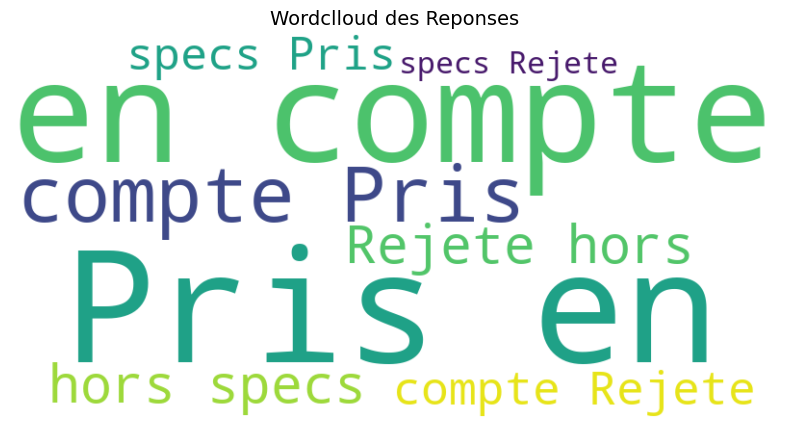

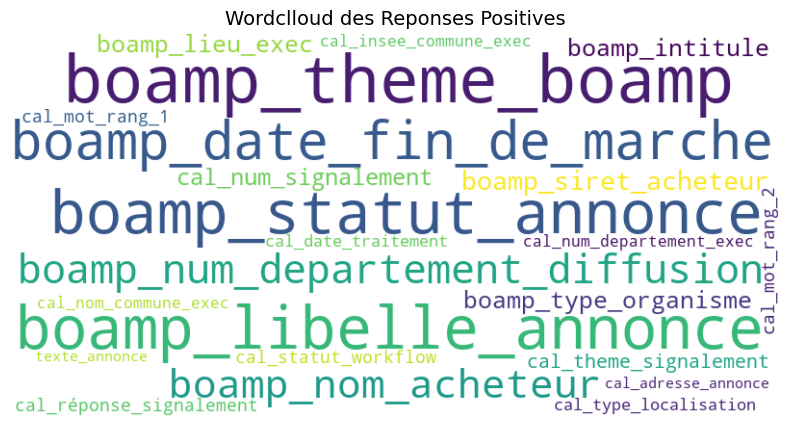

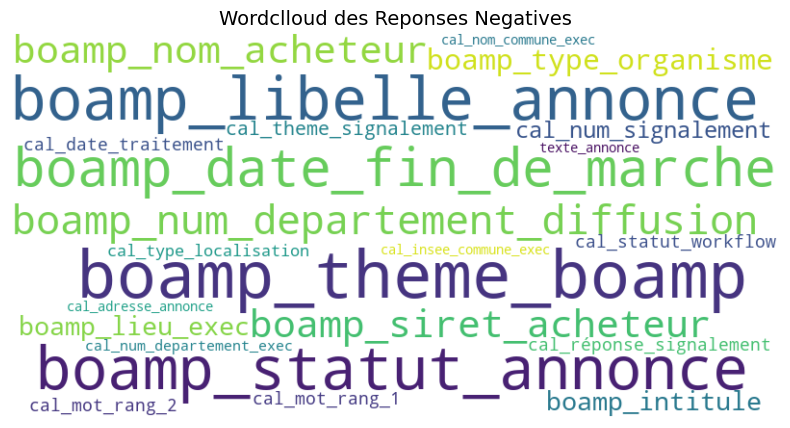

In [28]:
def generer_wordcloud(texte, titre):
    all_texte = ' '.join(texte)
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(all_texte)
    plt.figure(figsize=(10,5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(titre, fontsize=14)
    plt.axis('off')
    plt.show()
    

generer_wordcloud(df['cal_réponse_signalement'], 'Wordclloud des Reponses')
generer_wordcloud(df[df['cal_réponse_signalement']=='Pris en compte'], 'Wordclloud des Reponses Positives')
generer_wordcloud(df[df['cal_réponse_signalement']=='Rejete (hors specs)'], 'Wordclloud des Reponses Negatives')

## Variables Quantitatives

C:\Users\gauth\AppData\Local\Temp\ipykernel_28828\2222520737.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])
C:\Users\gauth\AppData\Local\Temp\ipykernel_28828\2222520737.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col])


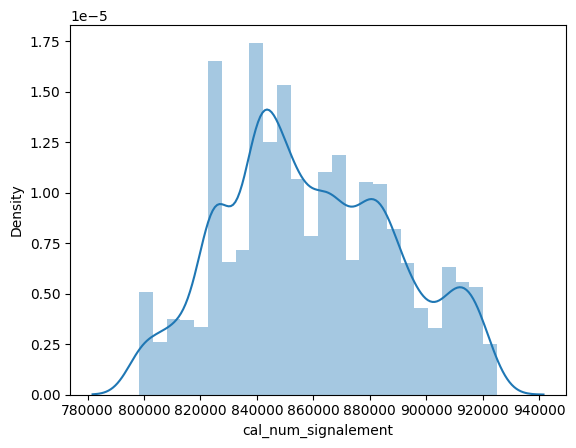

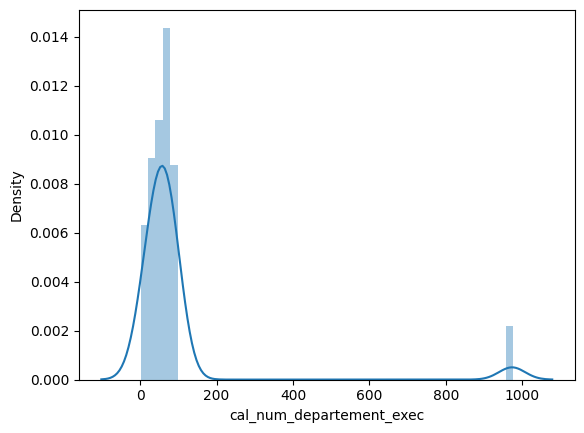

In [57]:
for col in df.select_dtypes('int64') :
    plt.figure()
    sns.distplot(df[col])

## Variables Qualitatives

Visualiser les différentes variables

In [60]:
for col in df.select_dtypes('object'):
    print(f'{col :-<50} {df[col].unique()}')

boamp_theme_boamp--------------------------------- ['Espaces verts' "Station d'épuration (travaux)"
 'Voirie et réseaux divers' ...
 'Electricité (travaux), Gros oeuvre, Menuiserie, Peinture (travaux), Prestations de services'
 'Bâtiment, Electricité (travaux), Gros oeuvre, Plomberie (travaux)'
 "Espaces verts, Ouvrage d'infrastructure, Ouvrage hydraulique, Voirie, Voirie et réseaux divers"]
boamp_libelle_annonce----------------------------- ['Avis de marché' 'Rectificatif' 'Modification' 'Résultat de marché']
boamp_statut_annonce------------------------------ ['INITIAL' 'RECTIFICATIF' 'MODIFICATION']
boamp_date_fin_de_marche-------------------------- ['2024-02-02' '2024-08-08' '2024-08-23' '2024-04-16' '2024-07-11'
 '2024-04-08' '2024-10-14' '2024-06-28' '2024-04-22' '2024-07-26'
 '2023-10-04' '2024-10-01' '2024-03-29' '2024-04-09' '2024-03-05'
 '2024-06-20' '2024-09-16' '2024-10-04' '2024-07-04' '2024-10-21'
 '2024-09-30' '2024-11-04' '2024-09-12' '2024-03-08' '2024-12-31'
 '2024-03-

# 2. PRE-PROCESSING - Création des sous-ensembles (suite au EDA)

In [31]:
df1 = data_train.copy()
df1.head()

,OGC_FID,boamp_id_annonce,boamp_parent_annonce,boamp_theme_boamp,boamp_libelle_annonce,boamp_statut_annonce,boamp_date_fin_de_marche,boamp_num_departement_diffusion,boamp_nom_acheteur,boamp_siret_acheteur,boamp_type_organisme,boamp_lieu_exec,boamp_intitule,cal_fichier_pdf,cal_num_signalement,cal_theme_signalement,cal_réponse_signalement,cal_statut_workflow,cal_mot_rang_1,cal_mot_rang_2,cal_date_traitement,cal_type_localisation,cal_num_departement_exec,cal_siren_epci,cal_insee_commune_exec,cal_nom_commune_exec,cal_adresse_annonce,texte_annonce
0,9723,23-177335,None,Espaces verts,Avis de marché,INITIAL,2024-02-02,31,TOULOUSE METROPOLE,24310051800170,TOULOUSE METROPOLE,,Travaux d'aménagement de l'île du Ramier à Tou...,https://fr.ftp.opendatasoft.com/datadila/BOAMP...,828298,Route,Pris en compte,50-signalement posté,travaux,aménagement,2023-12-22,loc_intitule_poi,31,243100518,31555,TOULOUSE,DÉCHÈTERIE DU RAMIER,Avis n° 23-177335\n \nAttention : les informa...
1,10502,24-63002,None,Station d'épuration (travaux),Avis de marché,INITIAL,2024-08-08,09,Syndicat Mixte Départemental de l'Eau et de l'...,25090187300019,COMMUNE,Parcelle n° 142 de la section ZB 09340 - VERNI...,Travaux de construction de la nouvelle station...,https://www.boamp.fr/telechargements/FILES/PDF...,870008,Points d'intérêt,Pris en compte,50-signalement posté,nouvelle,station,2024-05-30,loc_intitule_commune,9,,09332,VERNIOLLE,,1/3\nAvis de marché\nAttention : les informat...
2,10900,24-94957,['24-79402'],Voirie et réseaux divers,Rectificatif,RECTIFICATIF,2024-08-23,33,Bordeaux Métropole,24330031600011,,,"Aménagement de la place de la Renaudel, rues ...",https://www.boamp.fr/telechargements/FILES/PDF...,899670,Route,Pris en compte,50-signalement posté,aménagement,place,2024-08-14,loc_intitule_poi,33,243300316,33063,BORDEAUX,ÉGLISE SAINT LOUIS,1/1\nAvis rectificatif\nAttention : les infor...
3,779,23-179664,None,"Prestations de services, Délégation de service...",Avis de marché,INITIAL,2024-04-16,75,Ville de Paris,,,,Rénovation du parc de stationnement St Martin ...,https://fr.ftp.opendatasoft.com/datadila/BOAMP...,829274,Points d'intérêt,Rejete (hors specs),50-signalement posté,transformation,parc,2023-12-29,loc_acheteur_commune,75,,75056,PARIS,,Avis n° 23-179664\n \nAttention : les informa...
4,5614,24-69326,None,Génie civil,Avis de marché,INITIAL,2024-07-11,43,Département de la Haute-Loire,22430001200016,,Lieu-dit &quot;Basset&quot; 43210 - BAS-EN-BASSET,Rd12 - Reconstruction Du Pont Sur La Loire A B...,https://www.boamp.fr/telechargements/FILES/PDF...,876552,Route,Pris en compte,50-signalement posté,reconstruction,pont,2024-06-14,loc_lieu_exec_poi,43,,43020,BAS EN BASSET,BASSET,1/2\nAvis de marché\nAttention : les informat...


## Supprimer les colonnes inutiles + Gestion des valeurs nulles

In [32]:
#Formater les valeurs nulles en NA
df1.replace("None", np.nan, inplace=True)
df1.replace("", np.nan, inplace=True)

In [33]:
missing_rate = df1.isna().sum()/df1.shape[0]

In [34]:
df1 = df1[df1.columns[missing_rate < 0.8]] #Supprimer les colonnes avec plus de 80% données manquantes
df1 = df1.drop('OGC_FID', axis=1)
df1 = df1.drop('boamp_id_annonce', axis=1)
df1 = df1.drop('cal_fichier_pdf', axis=1)

In [35]:
# Transformation de la colonne cible 
df1['cal_réponse_signalement'] = df1['cal_réponse_signalement'].map({'Pris en compte': 1, 'Rejete (hors specs)': 0})

In [36]:
df1.head()

,boamp_theme_boamp,boamp_libelle_annonce,boamp_statut_annonce,boamp_date_fin_de_marche,boamp_num_departement_diffusion,boamp_nom_acheteur,boamp_siret_acheteur,boamp_type_organisme,boamp_lieu_exec,boamp_intitule,cal_num_signalement,cal_theme_signalement,cal_réponse_signalement,cal_statut_workflow,cal_mot_rang_1,cal_mot_rang_2,cal_date_traitement,cal_type_localisation,cal_num_departement_exec,cal_insee_commune_exec,cal_nom_commune_exec,cal_adresse_annonce,texte_annonce
0,Espaces verts,Avis de marché,INITIAL,2024-02-02,31,TOULOUSE METROPOLE,24310051800170,TOULOUSE METROPOLE,NaN,Travaux d'aménagement de l'île du Ramier à Tou...,828298,Route,1,50-signalement posté,travaux,aménagement,2023-12-22,loc_intitule_poi,31,31555,TOULOUSE,DÉCHÈTERIE DU RAMIER,Avis n° 23-177335\n \nAttention : les informa...
1,Station d'épuration (travaux),Avis de marché,INITIAL,2024-08-08,09,Syndicat Mixte Départemental de l'Eau et de l'...,25090187300019,COMMUNE,Parcelle n° 142 de la section ZB 09340 - VERNI...,Travaux de construction de la nouvelle station...,870008,Points d'intérêt,1,50-signalement posté,nouvelle,station,2024-05-30,loc_intitule_commune,9,09332,VERNIOLLE,NaN,1/3\nAvis de marché\nAttention : les informat...
2,Voirie et réseaux divers,Rectificatif,RECTIFICATIF,2024-08-23,33,Bordeaux Métropole,24330031600011,NaN,NaN,"Aménagement de la place de la Renaudel, rues ...",899670,Route,1,50-signalement posté,aménagement,place,2024-08-14,loc_intitule_poi,33,33063,BORDEAUX,ÉGLISE SAINT LOUIS,1/1\nAvis rectificatif\nAttention : les infor...
3,"Prestations de services, Délégation de service...",Avis de marché,INITIAL,2024-04-16,75,Ville de Paris,NaN,NaN,NaN,Rénovation du parc de stationnement St Martin ...,829274,Points d'intérêt,0,50-signalement posté,transformation,parc,2023-12-29,loc_acheteur_commune,75,75056,PARIS,NaN,Avis n° 23-179664\n \nAttention : les informa...
4,Génie civil,Avis de marché,INITIAL,2024-07-11,43,Département de la Haute-Loire,22430001200016,NaN,Lieu-dit &quot;Basset&quot; 43210 - BAS-EN-BASSET,Rd12 - Reconstruction Du Pont Sur La Loire A B...,876552,Route,1,50-signalement posté,reconstruction,pont,2024-06-14,loc_lieu_exec_poi,43,43020,BAS EN BASSET,BASSET,1/2\nAvis de marché\nAttention : les informat...


## Nettoyer les données TEXTE

Créer une fonction pour nettoyer le text

In [37]:
# Ajouter les valeurs autres que texte dans une liste
float_values = []

# Initialiser le modèle spaCy pour la lemmatisation
nlp = spacy.load('fr_core_news_sm')

# Ajouter des mots vides supplémentaires
additional_stop_words = set([
    "de", "d'", "l'", "la", "le", "les", 
    "des", "du", "un", "une", "en", "et", 
    "à", "au", "aux", "par", "pour", "sur", 
    "dans", "avec", "ce", "cette", "ces", "mon", 
    "ma", "mes", "ton", "ta", "tes", "son", "sa", 
    "ses", "notre", "nos", "votre", "vos", "leur", 
    "leurs", "ne", "pas", "plus", "moins", "ou", 
    "si", "oui", "non", "je", "tu", "il", "elle", 
    "nous", "vous", "ils", "elles", "me", "te", 
    "se", "moi", "toi", "lui", "leur", "y", "en", 
    "s'", "c'", "n'", "j'", "t'", "m'", "qu'", "l'"
])


stop_words = set(stopwords.words("french")).union(additional_stop_words)

def clean_text(text):
    if isinstance(text, float):
        float_values.append(text)
        return ''

    # Suppression des caractères spéciaux et de la ponctuation (conservation des lettres avec accents et apostrophes)
    text = re.sub(r'[^\w\s\']', '', text)

    # Conversion en minuscule
    text = text.lower()

    # Traitement du texte avec spaCy pour lemmatisation
    doc = nlp(text)

    # Suppression des mots vides
    lemmatized_tokens = [token.lemma_ for token in doc if token.text not in stop_words]

    # Joindre les tokens en une seule chaîne
    cleaned_text = ' '.join(lemmatized_tokens)

    return cleaned_text


Appliquer la fonction de nettoyage du texte sur les colonnes de type "object"

### 10min

In [38]:
# Appliquer la fonction clean_text à toutes les colonnes de type object 
for col in df1.select_dtypes(include=['object']).columns: 
    df1[col] = df1[col].apply(clean_text)

# Afficher les valeurs float détectées
print("Valeurs float détectées :", float_values)

Valeurs float détectées : [nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan, nan

In [39]:
df1.head()

,boamp_theme_boamp,boamp_libelle_annonce,boamp_statut_annonce,boamp_date_fin_de_marche,boamp_num_departement_diffusion,boamp_nom_acheteur,boamp_siret_acheteur,boamp_type_organisme,boamp_lieu_exec,boamp_intitule,cal_num_signalement,cal_theme_signalement,cal_réponse_signalement,cal_statut_workflow,cal_mot_rang_1,cal_mot_rang_2,cal_date_traitement,cal_type_localisation,cal_num_departement_exec,cal_insee_commune_exec,cal_nom_commune_exec,cal_adresse_annonce,texte_annonce
0,espace vert,avis marché,initial,20240202,31,toulous metropole,24310051800170,toulous metropole,,travail aménagement île ramier toulous ms6 ...,828298,route,1,50signalement poster,traval,aménagement,20231222,loc_intitule_poi,31,31555,toulous,déchèterie ramier,avis 23177335 \n \n attention information ...
1,station épuration traval,avis marché,initial,20240808,09,syndicat mixte départemental eau assainissement,25090187300019,commun,parcell 142 section zb 09340 verniolle,travail construction nouveau station épuration...,870008,point intérêt,1,50signalement poster,nouveau,station,20240530,loc_intitule_commune,9,09332,verniolle,,13 \n avis marché \n attention information...
2,voirie réseau divers,rectificatif,rectificatif,20240823,33,bordeaux métropole,24330031600011,,,aménagement place renaudel rue welle tauzia ...,899670,route,1,50signalement poster,aménagement,place,20240814,loc_intitule_poi,33,33063,bordeaux,église saint louis,11 \n avis rectificatif \n attention infor...
3,prestation service délégation service public,avis marché,initial,20240416,75,ville pari,,,,rénovation parc stationnement st martin pari c...,829274,point intérêt,0,50signalement poster,transformation,parc,20231229,loc_acheteur_commune,75,75056,pari,,avis 23179664 \n \n attention information ...
4,génie civil,avis marché,initial,20240711,43,département hauteloire,22430001200016,,lieudit quotbassetquot 43210 basenbasset,rd12 reconstruction pont loire avoir basenba...,876552,route,1,50signalement poster,reconstruction,pont,20240614,loc_lieu_exec_poi,43,43020,bas basset,basset,12 \n avis marché \n attention information...


## ENCODAGE : Transformer les valeurs Texte en valeurs Numérique (TF-IDF)

Pour chaque colonnes texte, faire une vectorisation avec TF-IDF afin de les transformer en float

In [40]:
def encodage(df):

    # Initialiser un DataFrame vide pour stocker les vecteurs TF-IDF
    tfidf_df = pd.DataFrame()

    # Appliquer TfidfVectorizer à chaque colonne de texte
    for col in df.select_dtypes(include=['object']).columns:
        
        # Création de l'instance de TfidfVectorizer 
        vectorizer = TfidfVectorizer()
        
        # Transformation du dataframe en une matrice TF-IDF 
        tfidf_matrix = vectorizer.fit_transform(df[col])
        
        # Créer un DataFrame pour la colonne TF-IDF
        tfidf_df_col = pd.DataFrame(tfidf_matrix.toarray(), columns=[f"{col}_{feature}" for feature in vectorizer.get_feature_names_out()])
        
        # Concaténer les résultats au DataFrame TF-IDF
        tfidf_df = pd.concat([tfidf_df, tfidf_df_col], axis=1)
        
    return tfidf_df
        


Ajouter les colonnes qui étaient déjà en numérique et créer un data frame final

### 25s

In [41]:
# Concaténer les colonnes numériques et la colonne cible au DataFrame TF-IDF 
final_df = pd.concat([encodage(df=df1).reset_index(drop=True), df1.select_dtypes(include=[np.number]).reset_index(drop=True)], axis=1)

Visualiser les dimensions finales

In [42]:
# Afficher la forme de la matrice TF-IDF 
print("Dimensions de la matrice de caractéristiques : ", final_df.shape)

Dimensions de la matrice de caractéristiques :  (5000, 108728)


In [43]:
# Afficher le DataFrame avec les vecteurs TF-IDF
final_df.head()

,boamp_theme_boamp_abonnement,boamp_theme_boamp_abonnemer,boamp_theme_boamp_abri,boamp_theme_boamp_accueil,boamp_theme_boamp_accès,boamp_theme_boamp_acier,boamp_theme_boamp_agricole,boamp_theme_boamp_air,boamp_theme_boamp_aire,boamp_theme_boamp_alarme,boamp_theme_boamp_alimentation,boamp_theme_boamp_amiant,boamp_theme_boamp_analyse,boamp_theme_boamp_antenn,boamp_theme_boamp_appareil,boamp_theme_boamp_archéologique,boamp_theme_boamp_arrosage,boamp_theme_boamp_art,boamp_theme_boamp_artificiel,boamp_theme_boamp_ascenseur,boamp_theme_boamp_assainissement,boamp_theme_boamp_assainissemer,boamp_theme_boamp_assistance,boamp_theme_boamp_assurance,boamp_theme_boamp_audiovisuel,boamp_theme_boamp_audit,boamp_theme_boamp_automatique,boamp_theme_boamp_aéronautique,boamp_theme_boamp_bardag,boamp_theme_boamp_bardage,boamp_theme_boamp_barrage,boamp_theme_boamp_bassin,boamp_theme_boamp_berge,boamp_theme_boamp_biologique,boamp_theme_boamp_boi,boamp_theme_boamp_bois,boamp_theme_boamp_busag,boamp_theme_boamp_bâtiment,boamp_theme_boamp_bâtimer,boamp_theme_boamp_canalisatier,boamp_theme_boamp_canalisation,boamp_theme_boamp_captage,boamp_theme_boamp_carburer,boamp_theme_boamp_carrelage,boamp_theme_boamp_chambre,boamp_theme_boamp_charpent,boamp_theme_boamp_charpente,boamp_theme_boamp_chaudronnerie,boamp_theme_boamp_chauffage,boamp_theme_boamp_chute,boamp_theme_boamp_cimetièr,boamp_theme_boamp_cimetière,boamp_theme_boamp_cinéma,boamp_theme_boamp_cinématographique,boamp_theme_boamp_civil,...,texte_annonce_évoquer,texte_annonce_évreu,texte_annonce_évreux,texte_annonce_évron,texte_annonce_évry,texte_annonce_évrycourcouronne,texte_annonce_évrycourcouronnes,texte_annonce_évènement,texte_annonce_évènementiel,texte_annonce_évènementielle,texte_annonce_évènementielproposition,texte_annonce_évèque,texte_annonce_événement,texte_annonce_événementiel,texte_annonce_évêque,texte_annonce_éxecution,texte_annonce_éxécution,texte_annonce_être,texte_annonce_êtreimpérativement,texte_annonce_île,texte_annonce_îledefrance,texte_annonce_îlegloriette,texte_annonce_îlot,texte_annonce_ø1000,texte_annonce_ø160,texte_annonce_ø200,texte_annonce_ø300,texte_annonce_ø600,texte_annonce_ø90,texte_annonce_œuvr,texte_annonce_œuvre,texte_annonce_œuvre25,texte_annonce_œuvre3,texte_annonce_œuvredémolition,texte_annonce_œuvredésamiantage,texte_annonce_œuvreexpérience,texte_annonce_œuvrefaçade,texte_annonce_œuvrel,texte_annonce_œuvrela,texte_annonce_œuvrele,texte_annonce_œuvrelot,texte_annonce_œuvremaçonnerie14,texte_annonce_œuvremaçonneriecarrelagefaïenceravalemer,texte_annonce_œuvremission,texte_annonce_œuvreo,texte_annonce_œuvrepour,texte_annonce_œuvreprésentation,texte_annonce_œuvreréceptionl,texte_annonce_œuvresemaf23,texte_annonce_œuvreseul,texte_annonce_œuvretranche,texte_annonce_œuvrevrdterrassementdémolition,cal_num_signalement,cal_réponse_signalement,cal_num_departement_exec
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.040842,0.0,0.129317,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.026509,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.026938,0.0,0.0,0.0,0.0,0.0,0.0,828298,1,31
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.046595,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,870008,1,9
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.

S'assurer qu'il ne reste plus de colonnes texte

In [44]:
final_df.dtypes.value_counts()

float64    108725
int64           3
Name: count, dtype: int64

<Axes: ylabel='count'>

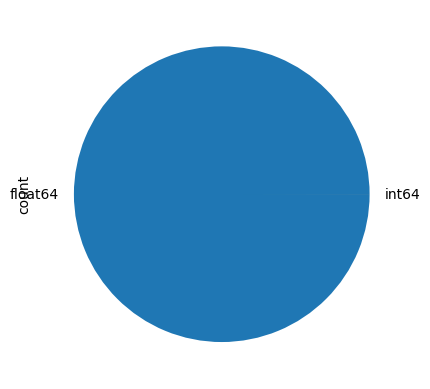

In [45]:
final_df.dtypes.value_counts().plot.pie()

# 3. Entrainement de notre modèle de prédiction

## TrainTest - Nettoyage - Encodage

In [46]:
trainset, testset = train_test_split(final_df, test_size=0.2, random_state=0)

Vérifier les proportions de réponses favorables et négatives dans nos données d'entrainement et de test

In [47]:
trainset['cal_réponse_signalement'].value_counts()

cal_réponse_signalement
1    2932
0    1068
Name: count, dtype: int64

In [48]:
testset['cal_réponse_signalement'].value_counts()

cal_réponse_signalement
1    719
0    281
Name: count, dtype: int64

In [49]:
def imputation(df):
    return df.dropna(axis=0)

In [51]:
def preprocessing(df):
    #df = encodage(final_df)
    df = imputation(df)
    
    X = df.drop('cal_réponse_signalement', axis = 1)
    y = df['cal_réponse_signalement']
    
    print(y.value_counts())
    
    return X, y
    

In [52]:
X_train, y_train = preprocessing(trainset)

cal_réponse_signalement
1    2932
0    1068
Name: count, dtype: int64


In [53]:
X_test, y_test = preprocessing(testset)

cal_réponse_signalement
1    719
0    281
Name: count, dtype: int64


### 40s

In [95]:
from sklearn.decomposition import TruncatedSVD

# Réduction de la dimensionnalité à, par exemple, 300 composantes
svd = TruncatedSVD(n_components=600)
X_train_reduced = svd.fit_transform(X_train)
X_test_reduced = svd.transform(X_test)


In [96]:
# Créer un DataFrame avec des noms de colonnes pour les composantes réduites 
feature_names = [f'Component_{i+1}' for i in range(X_train_reduced.shape[1])] 
X_train_reduced = pd.DataFrame(X_train_reduced, columns=feature_names)

## Modelisation

In [97]:
from sklearn.ensemble import GradientBoostingClassifier
from tensorflow.keras.models import Sequential 
from tensorflow.keras.layers import Dense, Dropout 
#from tensorflow.keras.wrappers.scikit_learn import KerasClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, ClassifierMixin


Ajout d'un pipeline de preprocessing

In [98]:
preprocessor = make_pipeline(PolynomialFeatures(2, include_bias=False), SelectKBest(f_classif, k=600))

Réseau de Neuronne

In [99]:
class KerasClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, build_fn=None, epochs=1, batch_size=32, verbose=0):
        self.build_fn = build_fn
        self.epochs = epochs
        self.batch_size = batch_size
        self.verbose = verbose
        self.model_ = None

    def fit(self, X, y):
        self.model_ = self.build_fn()
        self.model_.fit(X, y, epochs=self.epochs, batch_size=self.batch_size, verbose=self.verbose)
        return self

    def predict(self, X):
        return (self.model_.predict(X) > 0.5).astype("int32")


In [100]:
# Fonction pour créer le modèle Keras
def create_nn_model():
    model = Sequential()
    model.add(Dense(128, input_dim=X_train_reduced.shape[1], activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

Liste des modèles crées

In [101]:
RandomForest = make_pipeline(preprocessor, RandomForestClassifier(random_state=0))
AdaBoost = make_pipeline(preprocessor, AdaBoostClassifier(random_state=0))
SVM = make_pipeline(preprocessor, StandardScaler(), SVC(random_state=0))
KMN = make_pipeline(preprocessor, StandardScaler(), KNeighborsClassifier())
GradientBoosting = make_pipeline(preprocessor, GradientBoostingClassifier(random_state=0))
NeuralNetwork = make_pipeline(preprocessor, StandardScaler(), KerasClassifier(build_fn=create_nn_model, epochs=20, batch_size=32, verbose=0))

Liste des modèles à appliquer

In [102]:
dict_of_models = {
    #'RandomForest':RandomForest, 
    #'AdaBoost':AdaBoost, 
    #'SVM':SVM, 
    #'KMN':KMN, 
    #'GradientBoosting': GradientBoosting,
    'NeuralNetwork': NeuralNetwork
    }

## Procédure d'évaluation

Fonction d'exécution de mes modèles

In [103]:
def evaluation(model, X_train, X_test):
    model.fit(X_train, y_train)
    ypred = model.predict(X_test)
    
    print(confusion_matrix(y_test, ypred))
    print(classification_report(y_test, ypred))
    
    N, train_score, val_score = learning_curve(model, X_train, y_train,
                                               cv=4, scoring='f1',
                                               train_sizes=np.linspace(0.1,1,10))
    
    
    plt.figure(figsize=(12,8))
    plt.plot(N, train_score.mean(axis=1), label='train score')
    plt.plot(N, val_score.mean(axis=1), label='validation score')
    plt.legend()

### 10min

In [ ]:
for name, model in dict_of_models.items():
    print(name)
    evaluation(model, X_train, X_test)

### 5min 30s

In [104]:
for name, model in dict_of_models.items():
    print(name)
    evaluation(model, X_train_reduced, X_test_reduced)

NeuralNetwork


C:\Users\gauth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\gauth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but PolynomialFeatures was fitted with feature names
  warnings.warn(


32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
[[ 99 182]
 [105 614]]
              precision    recall  f1-score   support

           0       0.49      0.35      0.41       281
           1       0.77      0.85      0.81       719

    accuracy                           0.71      1000
   macro avg       0.63      0.60      0.61      1000
weighted avg       0.69      0.71      0.70      1000



C:\Users\gauth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\gauth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py:982: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\gauth\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\model_selection\_validation.py", line 971, in _score
    scores = scorer(estim

KeyboardInterrupt: 

In [ ]:
pd.DataFrame(model.feature_importances_, index=X_train.columns)

In [50]:
pd.DataFrame(model.feature_importances_, index=X_train_reduced.columns).plot.bar(figsize = (12,8))

AttributeError: 'Pipeline' object has no attribute 'feature_importances_'